# Predicting the PD-1/PD-L1 Immune Checkpoint Interface with ESMFold2: Validating an AI-Generated Protein Complex Against Experimental Structure

In [1]:

# ============================================================
# PROJECT 3 (Option A): Predict a protein-protein COMPLEX,
# not just a single protein - and check if the interface looks real.
#
# We're using PD-1 and PD-L1 - real proteins central to how the immune
# system decides whether to attack cancer cells. PD-L1 sits on a cell's
# surface as a "don't attack me" signal; PD-1 is the receptor on immune
# T-cells that reads that signal. Cancer immunotherapy drugs
# (e.g. pembrolizumab/Keytruda, atezolizumab/Tecentriq) work by blocking
# this exact interaction, so immune cells stop being told to stand down.
#
# The real solved structure of the two proteins bound together is
# PDB entry 4ZQK. We'll fold them together ourselves and compare.
# ===========================================================

--- STEP 0: Install packages ---

In [2]:
!pip install -q esm@git+https://github.com/Biohub/esm.git@main
!pip install -q biopython pymol-open-source matplotlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.7/302.7 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import urllib.request
from Bio import SeqIO

--- STEP 1: Get the real sequences from the solved complex ---

In [4]:
PDB_ID = "4ZQK"
urllib.request.urlretrieve(f"https://files.rcsb.org/download/{PDB_ID}.pdb", f"{PDB_ID}.pdb")

with open(f"{PDB_ID}.pdb") as handle:
  records = list(SeqIO.parse(handle, "pdb-seqres"))

print(f"Found {len(records)} chains in {PDB_ID}:\n")

for r in records:
  print(f"Chain {r.id} | lentgh {len(r.seq)} | {r.description}")
  print(f" {r.seq}\n")

# The two chains we actually want are PD-1 and PD-L1 - identify them by
# their UniProt entry name in the description (PD1L1_HUMAN = PD-L1,
# PDCD1_HUMAN = PD-1) rather than hardcoding a chain letter.

pd1_record = next((r for r in records if "PDCD1_HUMAN" in r.description), None)
pdl1_record = next((r for r in records if "PD1L1_HUMAN" in r.description), None)


if pd1_record is None or pdl1_record is None:
    print("Couldn't auto-identify both chains from their descriptions.")
    print("Look at the printed chains above and set these manually, e.g.:")
    print("  pd1_record = records[0] ; pdl1_record = records[1]")
else:
    print(f"Identified PD-1 as chain {pd1_record.id}, PD-L1 as chain {pdl1_record.id}")

pd1_sequence = str(pd1_record.seq)
pdl1_sequence = str(pdl1_record.seq)


Found 2 chains in 4ZQK:

Chain 4ZQK:A | lentgh 115 | UNP:Q9NZQ7 PD1L1_HUMAN
 AFTVTVPKDLYVVEYGSNMTIECKFPVEKQLDLAALIVYWEMEDKNIIQFVHGEEDLKVQHSSYRQRARLLKDQLSLGNAALQITDVKLQDAGVYRCMISYGGADYKRITVKVNA

Chain 4ZQK:B | lentgh 118 | UNP:Q15116 PDCD1_HUMAN
 NPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMSPSNQTDKLAAFPEDRSQPGQDSRFRVTQLPNGRDFHMSVVRARRNDSGTYLCGAISLAPKAQIKESLRAELRVTERRAE

Identified PD-1 as chain 4ZQK:B, PD-L1 as chain 4ZQK:A


--- STEP 2: Set up your Biohub API client ---

In [ ]:
from esm.sdk.forge import SequenceStructureForgeInferenceClient
from esm.sdk.api import FoldingConfig
from esm.utils.structure.input_builder import ProteinInput, StructurePredictionInput

BIOHUB_TOKEN = 'INSERT HERE YOUR OWN FREE BIOHUB TOKEN'

client = SequenceStructureForgeInferenceClient(
    model = "esmfold2-fast-2026-05",
    url="https://biohub.ai",
    token = BIOHUB_TOKEN,
)

 --- STEP 3: Fold them TOGETHER as one complex (this is the new part - ---
 --- multiple chains in one prediction, not one protein at a time)     ---

In [6]:
struct_input = StructurePredictionInput(
    sequences = [
        ProteinInput(id="A", sequence=pd1_sequence),
        ProteinInput(id="B", sequence=pdl1_sequence),
    ]
)

config = FoldingConfig(num_loops = 20, num_sampling_steps=100)

print("\nFolding PD-L1 + PD-1 together as a complex...")
result = client.fold_all_atom(struct_input, config=config)

from esm.sdk.api import ESMProteinError

if isinstance(result, ESMProteinError):
  print("The API returned an error instead of a prediction. Details:")
  print(f"  Type: {type(result)}")
  print(f"  str(result): {str(result)}")
  print(f"  repr(result): {repr(result)}")
  print(f"  Available attributes/methods: {[a for a in dir(result) if not a.startswith('_')]}")
  for attr_name in ["error", "error_type", "error_code", "message", "error_message", "status_code", "detail"]:
      if hasattr(result, attr_name):
            print(f"  .{attr_name} = {getattr(result, attr_name)}")
  raise RuntimeError(
      "Folding failed - see the error details above. Common causes: combined "
      "sequence length limits, malformed ProteinInput, or an invalid config "
      "parameter. Fix based on the actual message above, then re-run."
    )

print(f"Mean pLDDT (confidence): {float(result.plddt.mean()):.3f}")
print(f"pTM (overall fold confidence): {float(result.ptm):.3f}")

# Try to find an interface-specific confidence metric - field name isn't
# documented, so check a few plausible attributes rather than assume one.

for attr_name in ["ipae","pae","iptm","interface_confidence"]:
  if hasattr(result, attr_name):
    value = getattr(result,attr_name)
    print(f"Found '{attr_name}': {value}")

with open("predicted_complex.cif", "w") as f:
  f.write(result.complex.to_mmcif())

print("Saved -> predicted_complex.cif")


Folding PD-L1 + PD-1 together as a complex...
Mean pLDDT (confidence): 0.886
pTM (overall fold confidence): 0.909
Found 'pae': None
Found 'iptm': 0.8889926075935364
Saved -> predicted_complex.cif


STEP 4: The real test - do the two chains actually TOUCH in the ---
 --- predicted structure? Measure it directly with distances.

In [7]:
from Bio.PDB import MMCIFParser, PDBParser

parser = MMCIFParser(QUIET=True)
predicted_structure = parser.get_structure("predicted", "predicted_complex.cif")
model = predicted_structure[0]
chain_A = model["A"]
chain_B = model["B"]

CONTACT_THRESHOLD = 5.0 # Angstroms - standard cutoff for "these residues are touching"

def count_atomic_contacts(chain_a, chain_b, threshold = CONTACT_THRESHOLD):
  """Count residue pairs where ANY atom in one residue is within `threshold`
    of ANY atom in the other - this is the real, standard way interface
    contacts are defined (CA-only badly undercounts, since backbone atoms
    sit further apart than the side chains that actually touch)."""
  contact_count = 0
  contact_pairs = []
  for res_a in chain_a:
    if res_a.id[0]!=" ": #skip water/heteroatoms
      continue
    for res_b in chain_b:
      if res_b.id[0]!=" ": #skip water/heteroatoms
        continue
      if any(
          (atom_a - atom_b)<threshold
          for atom_a in res_a
          for atom_b in res_b
      ):
        contact_count +=1
        contact_pairs.append((res_a.id[1], res_b.id[1]))
  return contact_count, contact_pairs

predicted_contact_count, predicted_contact_pairs = count_atomic_contacts(chain_A, chain_B)


print(f"\nAll-atom contact count (predicted complex): {predicted_contact_count} residue pairs "
  f"within {CONTACT_THRESHOLD} Angstroms")

if predicted_contact_count > 5:
  print("This looks like a real interface - multiple residues are actually touching,")
  print("not just two chains floating near each other.")
else:
  print("Very few contacts - worth inspecting the structure visually.")




All-atom contact count (predicted complex): 75 residue pairs within 5.0 Angstroms
This looks like a real interface - multiple residues are actually touching,
not just two chains floating near each other.


--- STEP 5: Render and view the predicted complex ---

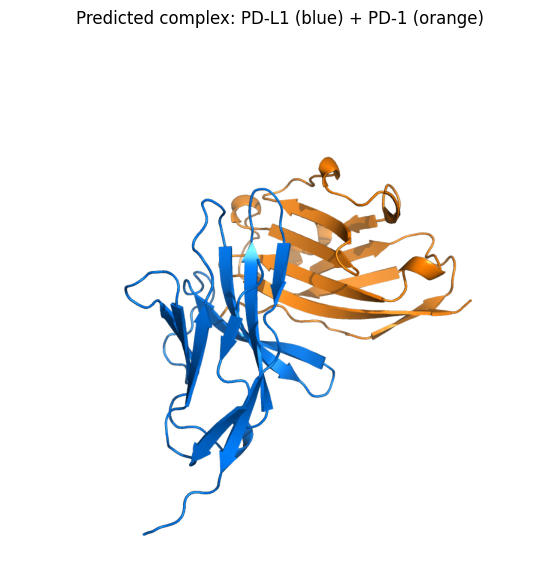

In [11]:
import pymol
from pymol import cmd

pymol.finish_launching(["pymol", "-qc"])

cmd.load("predicted_complex.cif", "complex")
cmd.hide("everything")
cmd.show("cartoon")
cmd.color("marine", "complex and chain A")
cmd.color("orange", "complex and chain B")
cmd.bg_color("white")
cmd.zoom("complex", buffer=3)
cmd.ray(900, 900)
cmd.png("predicted_complex.png", dpi=150)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("predicted_complex.png")
plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis("off")
plt.title("Predicted complex: PD-L1 (blue) + PD-1 (orange)")
plt.show()

 --- STEP 6: The definitive check - align the predicted complex against ---

 --- the REAL solved structure (4ZQK) and measure actual RMSD.         ---

 We already downloaded 4ZQK.pdb in Step 1. cealign here aligns the whole
 COMPLEX (both chains at once), so this tests not just "is each protein
 folded right" but "did the model get their relative orientation right too" -
 a much stronger test than pLDDT/iPTM alone.


--- Structural alignment: predicted complex vs. real 4ZQK ---
Raw cealign result: {'alignment_length': 128, 'RMSD': 6.4814762765890706, 'rotation_matrix': [1.0, -3.228021655532487e-09, -1.51905835132915e-08, 5.176929680630565, 3.2280218914548797e-09, 0.9999999999999998, 1.2181366360053403e-08, 49.70762503147125, 1.5190583360635834e-08, -1.2181366360053403e-08, 0.9999999999999999, 106.07548427581787, -5.176929457345977, -49.707627922296524, -106.07548451423645, 1.0]}

RMSD: 6.48 Angstroms
Aligned length: 128 residues (out of 233 total)
(Under ~2-3 Angstroms across most of the complex = the model correctly predicted
both the individual folds AND how they're oriented against each other.)

All-atom contact count (REAL structure): 56 residue pairs
All-atom contact count (predicted):        75 residue pairs
(These won't match exactly, but should be in a similar range if the
prediction genuinely captured the real interface.)


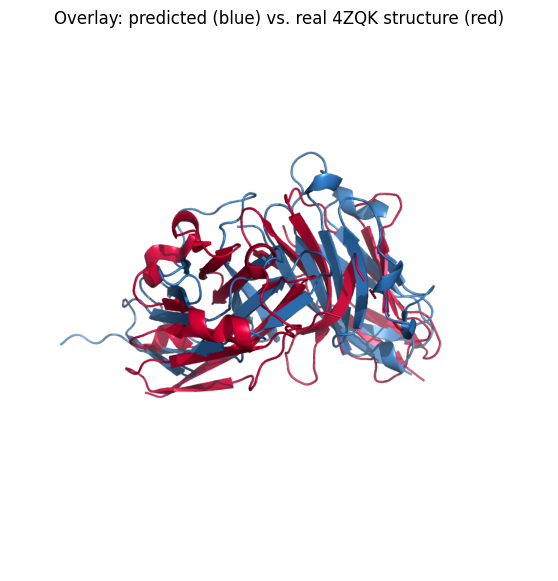


If this worked well, you should see the blue and red complex chains pressed
together at an interface - not two separate blobs floating apart.
That's the model correctly recognizing that these two real proteins bind.


In [19]:
cmd.load(f"{PDB_ID}.pdb", "real_complex")

align_result = cmd.cealign("real_complex", "complex")
print("\n--- Structural alignment: predicted complex vs. real 4ZQK ---")
print("Raw cealign result:", align_result)

rmsd = align_result.get("RMSD")
aligned_len = align_result.get("alignment_length")
print(f"\nRMSD: {rmsd:.2f} Angstroms" if rmsd is not None else "RMSD not returned")
print(f"Aligned length: {aligned_len} residues (out of {len(pdl1_sequence) + len(pd1_sequence)} total)"
      if aligned_len is not None else "")
print("(Under ~2-3 Angstroms across most of the complex = the model correctly predicted")
print("both the individual folds AND how they're oriented against each other.)")


# For comparison: how many contacts exist in the REAL structure? This tells
# us whether our predicted contact count (above) is in the right ballpark.

real_parser = PDBParser(QUIET=True)
real_structure = real_parser.get_structure("real", f"{PDB_ID}.pdb")
real_model = real_structure[0]
real_chain_A = real_model["A"]
real_chain_B = real_model["B"]

real_contact_count, _ = count_atomic_contacts(real_chain_A, real_chain_B)
print(f"\nAll-atom contact count (REAL structure): {real_contact_count} residue pairs")
print(f"All-atom contact count (predicted):        {predicted_contact_count} residue pairs")
print("(These won't match exactly, but should be in a similar range if the")
print("prediction genuinely captured the real interface.)")

# Render the overlay itself

cmd.hide("everything")
cmd.show("cartoon")
cmd.color("skyblue", "complex")
cmd.color("bohrium","real_complex")
cmd.bg_color("white")
cmd.zoom("all", buffer=3)
cmd.ray(900,900)
cmd.png("complex_overlay.png", dpi=150)

img_overlay = mpimg.imread("complex_overlay.png")
plt.figure(figsize=(7,7))
plt.imshow(img_overlay)
plt.axis("off")
plt.title("Overlay: predicted (blue) vs. real 4ZQK structure (red)")
plt.show()

print("\nIf this worked well, you should see the blue and red complex chains pressed")
print("together at an interface - not two separate blobs floating apart.")
print("That's the model correctly recognizing that these two real proteins bind.")

 --- STEP 7: View just the real experimental structure on its own ---

 "real_complex" is already loaded from Step 6 - no need to reload the file

 or re-import pymol/matplotlib, just hide the predicted one and re-render.

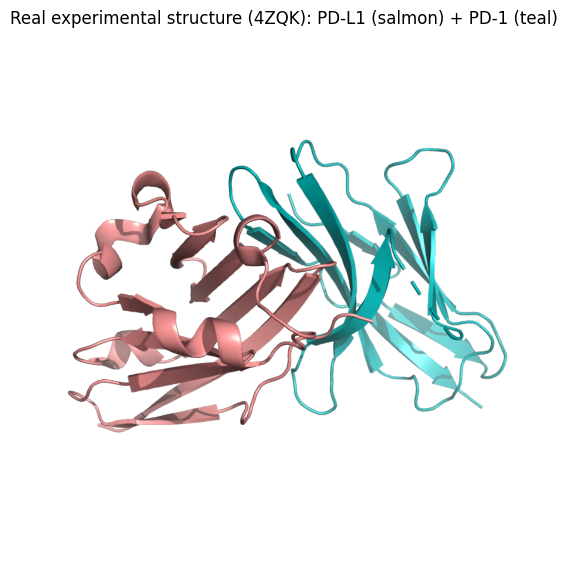


This is the actual crystallography result - no AI prediction involved.
Compare this by eye to your predicted_complex.png from Step 5.


In [21]:
cmd.hide("everything","complex")
cmd.show("cartoon","real_complex")
cmd.color("salmon", "real_complex and chain A") #PD-L1
cmd.color("teal","real_complex and chain B") #PD-1
cmd.zoom("real_complex", buffer=3)
cmd.ray(900,900)
cmd.png("real_structure_only.png", dpi=150)

img_real_only = mpimg.imread("real_structure_only.png")
plt.figure(figsize=(7,7))
plt.imshow(img_real_only)
plt.axis("off")
plt.title("Real experimental structure (4ZQK): PD-L1 (salmon) + PD-1 (teal)")
plt.show()

print("\nThis is the actual crystallography result - no AI prediction involved.")
print("Compare this by eye to your predicted_complex.png from Step 5.")